## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### scikit-learn Libraries

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Set Visulization Style

In [4]:
sns.set_style("whitegrid")

### Load Data

In [5]:
# Load built-in Iris dataset
iris = load_iris()

# Create a DataFrame from the Iris dataset
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

#add the target / species column to the DataFrame
df['species'] = iris.target

# Map numberical target values to species names
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Understand the Dataset

In [6]:
# display dataset shape
print(f"Dataset shape: {df.shape}")

# display column names
print(f"Column names: {df.columns.tolist()}")

# Display datatype
print(f"Data types:\n{df.dtypes}")

Dataset shape: (150, 5)
Column names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']
Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object


### Check for Missing Values

In [7]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


### Descriptive Statistics

In [8]:
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


## species Distribution

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_3652\3365262824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, palette='Set2')


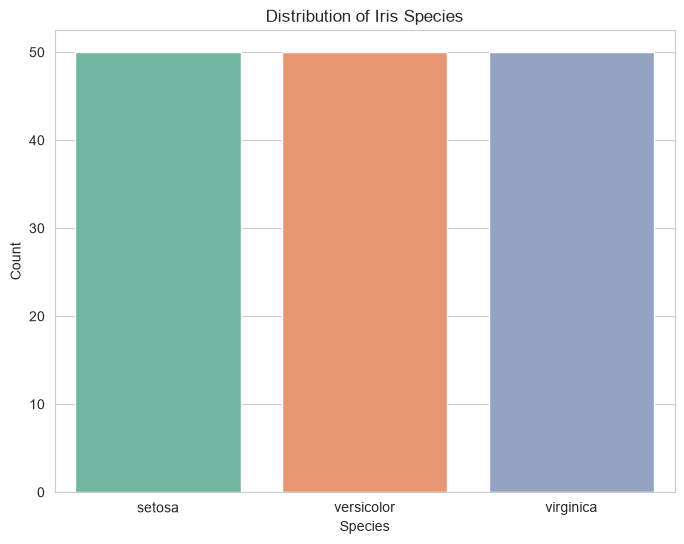

In [9]:
# count observations for each species
print(df['species'].value_counts())

# Visualize the distribution of species in the dataset
plt.figure(figsize=(8, 6))
sns.countplot(x='species', data=df, palette='Set2')
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()


## Pairploe

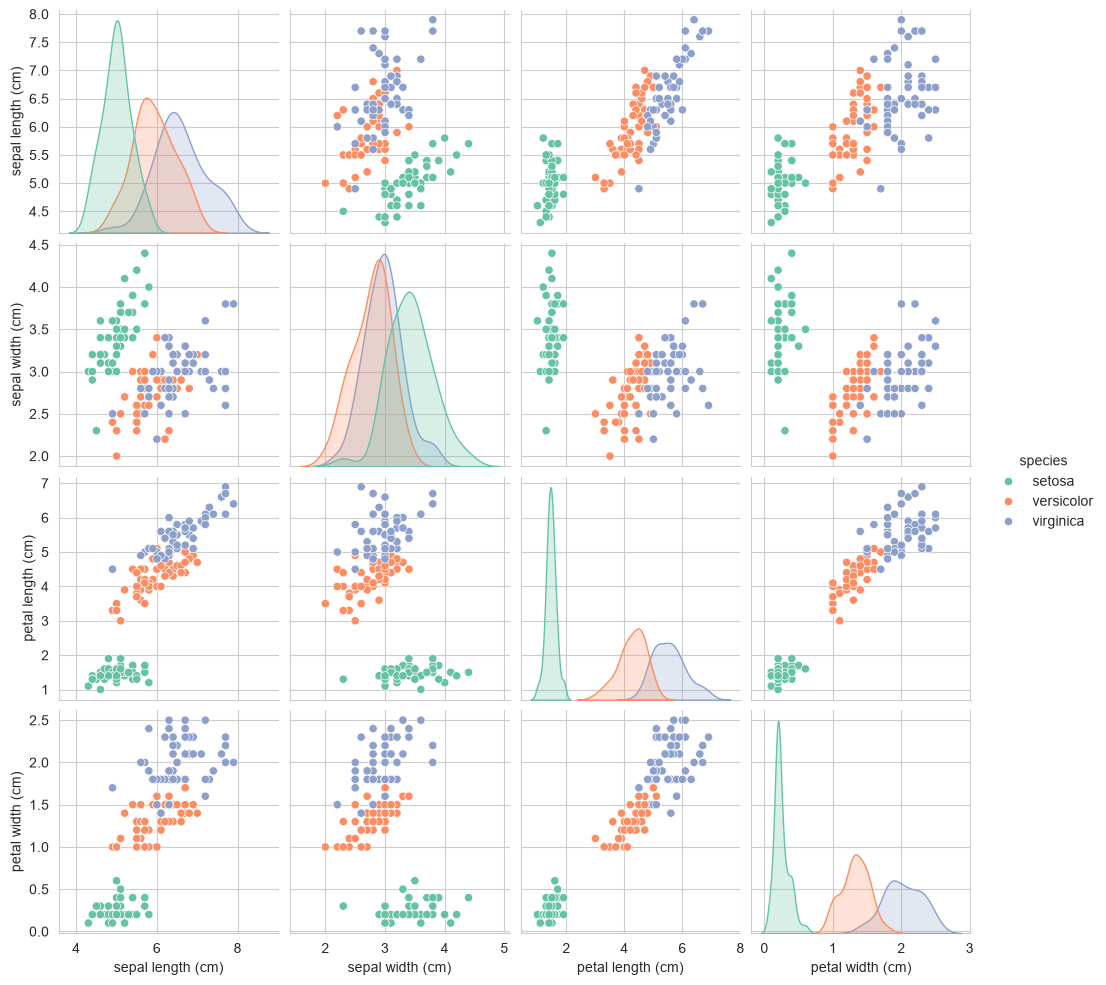

In [10]:
# Pairplot to visualize relationships between features
sns.pairplot(df, hue='species', palette='Set2')
plt.show()

## Box Plot

C:\Users\HP\AppData\Local\Temp\ipykernel_3652\1408146298.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_3652\1408146298.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_3652\1408146298.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_3652\1408146298.py:6: FutureWarn

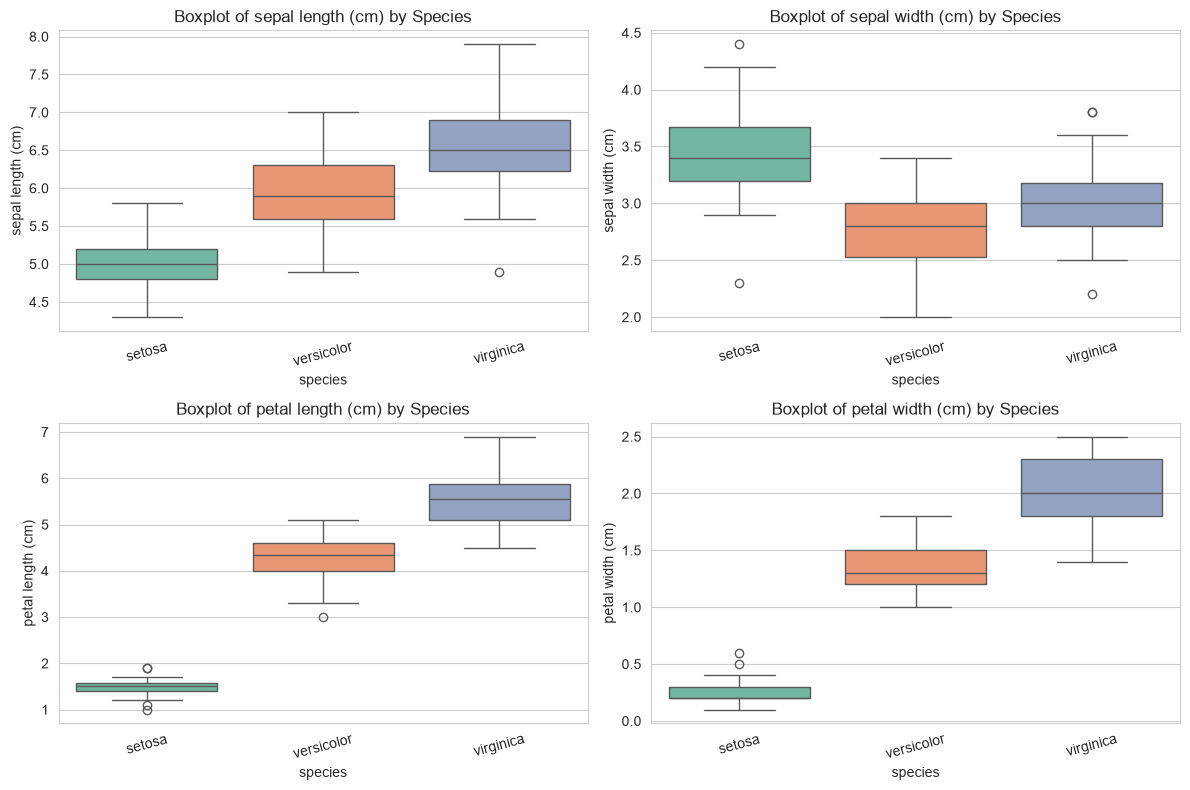

In [11]:
# create a Boxplot for all features grouped by species
features = iris.feature_names
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='species', y=feature, data=df, palette='Set2')
    plt.title(f'Boxplot of {feature} by Species')
    plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Prepare Features and Target

In [12]:
#Feature selection and model training
# Split the dataset into features and target variable
X = df[iris.feature_names]
# Target variable
y = df['species']

# diplay shape
print(f"Features shape: {X.shape}, Target shape: {y.shape}")


Features shape: (150, 4), Target shape: (150,)


## Train/Test Split

In [13]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}, Testing set shape: {X_test.shape}")

Training set shape: (120, 4), Testing set shape: (30, 4)


## Feature Scaling

In [14]:
# creat standard scaler instance
scaler = StandardScaler()

# fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)

# tranform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

## Model 1 — Logistic Regression

In [17]:
# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Calculate accuracy
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:",
      logistic_accuracy)

Logistic Regression Accuracy: 0.9333333333333333


## Logistic Regression Evaluation

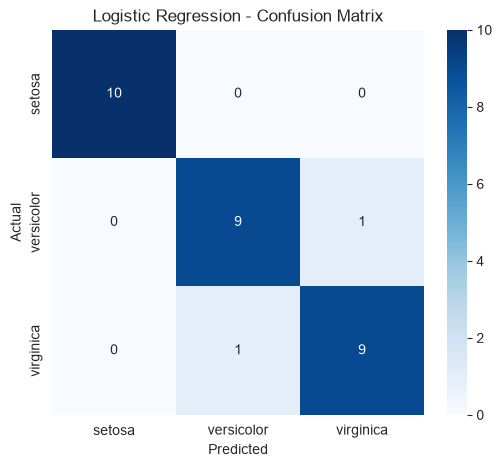

In [18]:
# Confusion Matrix

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# Classification report

print("Logistic Regression Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=iris.target_names
    )
)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## Model 2 — K-Nearest Neighbours

In [21]:
knn_model = KNeighborsClassifier(n_neighbors=5)

# train the model
knn_model.fit(X_train_scaled, y_train)

# Make predictions

y_pred_knn = knn_model.predict(X_test_scaled)

# Calculate Accuracy

knn_accuracy = accuracy_score( y_test,y_pred_knn)


## Confusion Matrix

In [24]:
# Classification report

print("KNN Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [25]:
# Compare model accuracy

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbours"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbours,0.933333


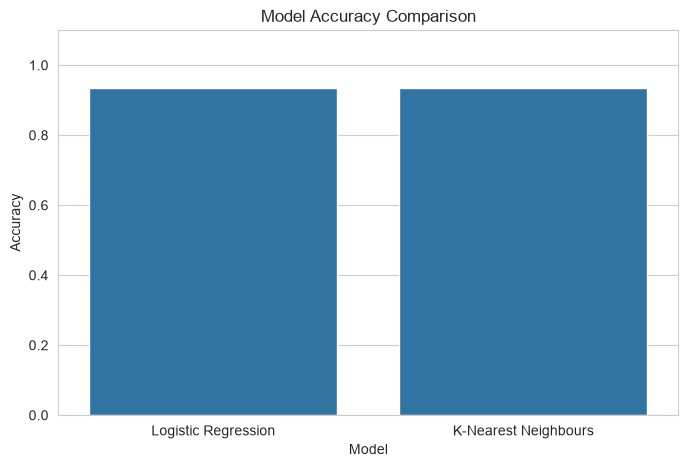

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

In [27]:
# Find the model with the highest accuracy

best_model_row = results.loc[
    results["Accuracy"].idxmax()
]

print("Best Model:", best_model_row["Model"])
print("Best Accuracy:", best_model_row["Accuracy"])

Best Model: Logistic Regression
Best Accuracy: 0.9333333333333333
